# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Alvaro Acaro

**Fecha:** 28/06/2026  

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [6]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [8]:
from google.colab import files

print("Por favor, sube el archivo 'car.data' a tu sesión de Colab.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Archivo "{fn}" subido con éxito.')

Por favor, sube el archivo 'car.data' a tu sesión de Colab.


Saving car.data to car (1).data
Archivo "car (1).data" subido con éxito.


In [10]:
# TODO: Cargar el dataset car.data

# 1. Definir los nombres de las columnas
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# 2. Cargar el dataset
df = pd.read_csv('car (1).data', header=None, names=col_names)

# 3. Imprimir las dimensiones del dataset
print("Dimensiones del dataset:", df.shape)

# 4. Mostrar las primeras 5 filas
df.head()

Dimensiones del dataset: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B) 1728 muestras, 7 características

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [11]:
# TODO: Explorar información del dataset

# 1. Ver información general del dataset
print("Información del dataset:")
df.info()

# 2. Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
df.describe(include='all')


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

Estadísticas descriptivas:


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [12]:
# TODO: Verificar valores únicos por columna

# Recorrer cada columna e imprimir sus valores únicos
for col in df.columns:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: buying
['vhigh' 'high' 'med' 'low']

Columna: maint
['vhigh' 'high' 'med' 'low']

Columna: doors
['2' '3' '4' '5more']

Columna: persons
['2' '4' 'more']

Columna: lug_boot
['small' 'med' 'big']

Columna: safety
['low' 'med' 'high']

Columna: class
['unacc' 'acc' 'vgood' 'good']


In [13]:
# TODO: Verificar valores nulos

# Contar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())



Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


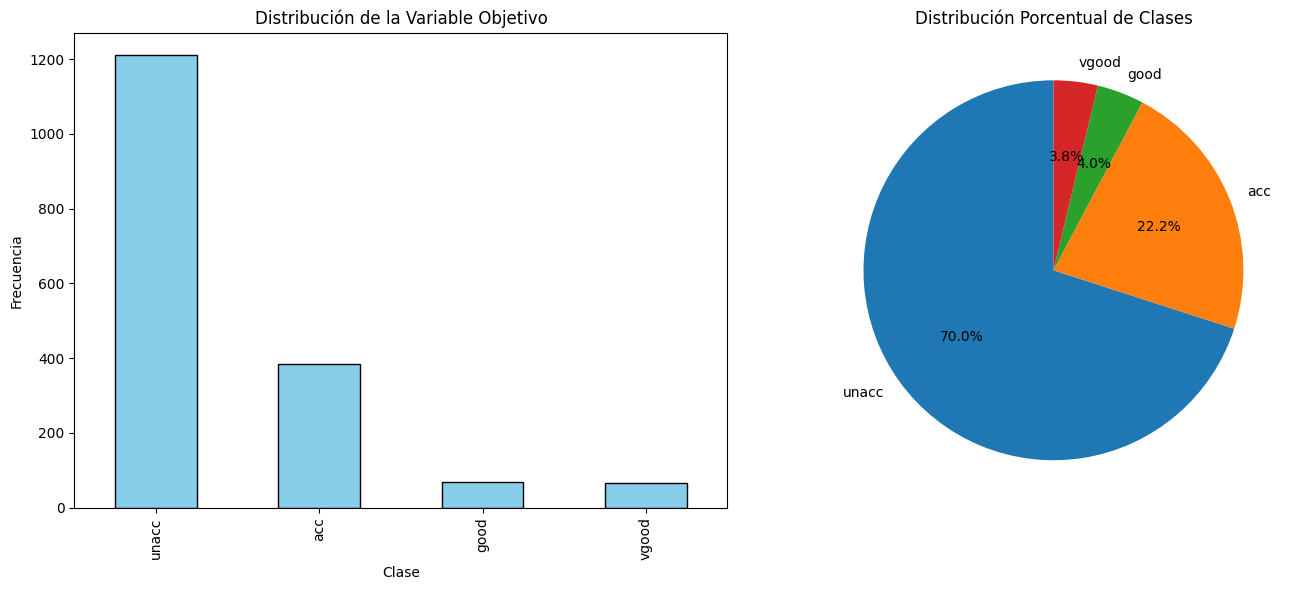

Conteo de clases:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [15]:
# Crear una figura con 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
df['class'].value_counts().plot(
    kind='bar',
    ax=ax[0],
    color='skyblue',
    edgecolor='black'
)
ax[0].set_title('Distribución de la Variable Objetivo')
ax[0].set_xlabel('Clase')
ax[0].set_ylabel('Frecuencia')

# Gráfico de pastel
df['class'].value_counts().plot(
    kind='pie',
    ax=ax[1],
    autopct='%1.1f%%',
    startangle=90
)
ax[1].set_title('Distribución Porcentual de Clases')
ax[1].set_ylabel('')

# Ajustar el diseño
plt.tight_layout()
plt.show()

# Imprimir el conteo de clases
print("Conteo de clases:")
print(df['class'].value_counts())



### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C) unacc (inaceptable)  

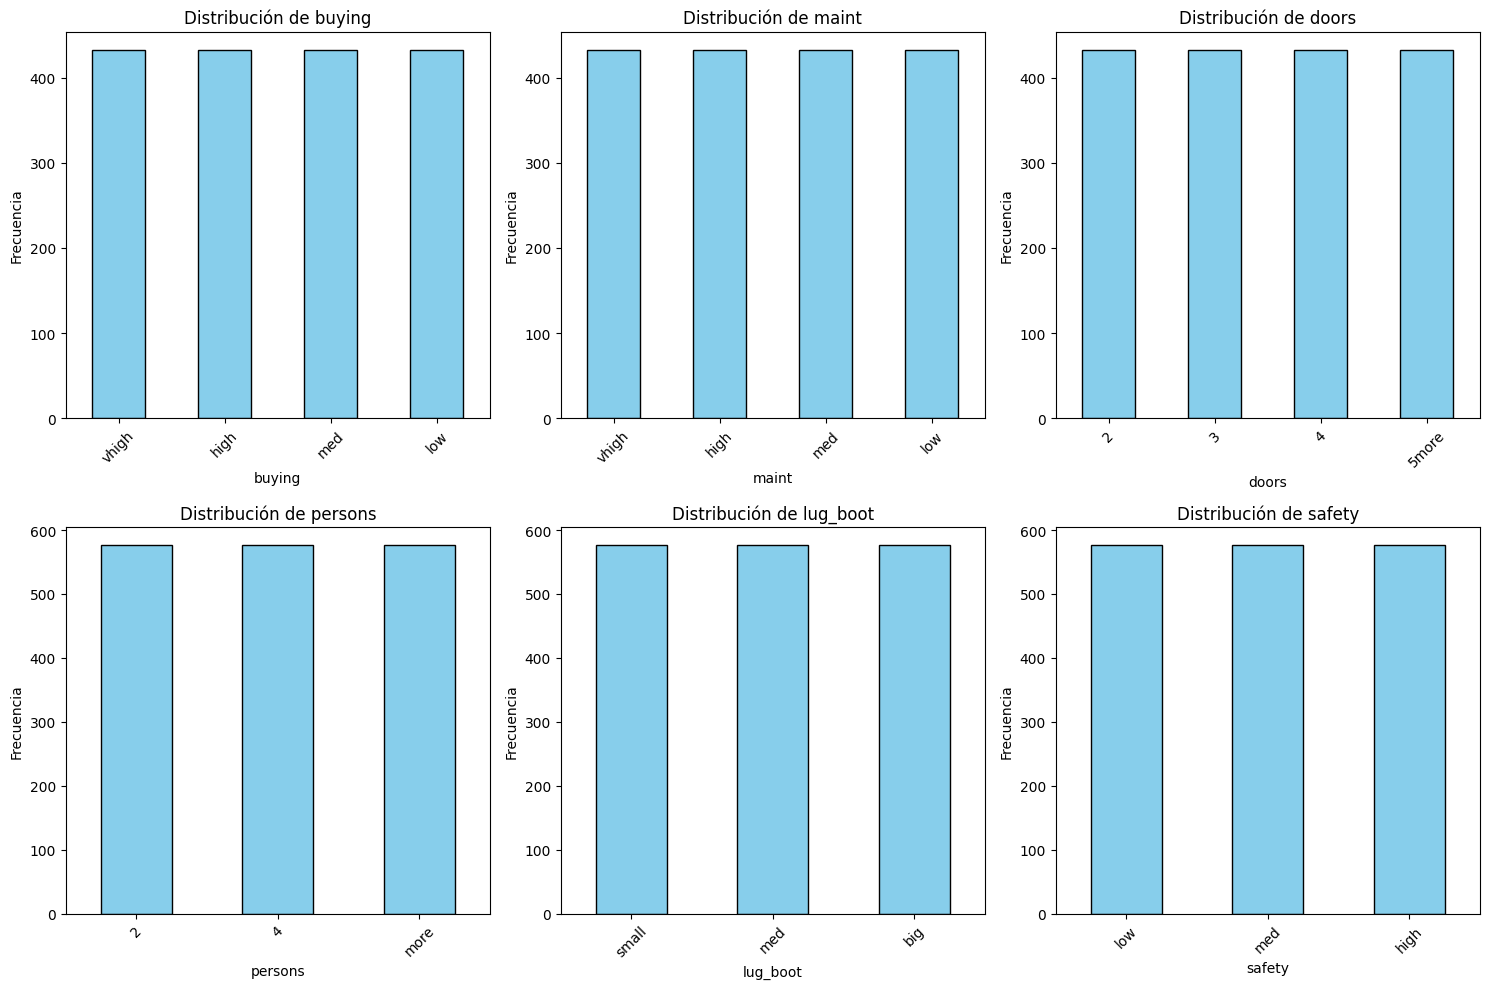

In [16]:
# Definir las características
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

# Crear la figura con subplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Convertir la matriz de ejes en un arreglo unidimensional
axes = axes.ravel()

# Graficar cada característica
for i, feature in enumerate(features):
    df[feature].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color='skyblue',
        edgecolor='black'
    )
    axes[i].set_title(f'Distribución de {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

# Ajustar el diseño
plt.tight_layout()
plt.show()



### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [17]:
# 1. Crear una copia del DataFrame
df_encoded = df.copy()

# 2. Crear un diccionario para guardar los LabelEncoders
label_encoders = {}

# 3. Aplicar Label Encoding a cada columna
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# 4. Mostrar las primeras filas del DataFrame codificado
print("Primeras 5 filas del DataFrame codificado:")
df_encoded.head()



Primeras 5 filas del DataFrame codificado:


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [18]:
# TODO: Mostrar el mapeo de etiquetas

# Mostrar el mapeo de cada LabelEncoder
for col, le in label_encoders.items():
    print(f"\nColumna: {col}")
    print(dict(zip(le.classes_, range(len(le.classes_)))))




Columna: buying
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Columna: maint
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Columna: doors
{'2': 0, '3': 1, '4': 2, '5more': 3}

Columna: persons
{'2': 0, '4': 1, 'more': 2}

Columna: lug_boot
{'big': 0, 'med': 1, 'small': 2}

Columna: safety
{'high': 0, 'low': 1, 'med': 2}

Columna: class
{'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B) Convierte categorías a valores numéricos enteros

## Parte 4: División de Datos

In [19]:
# 1. Obtener las características
X = df_encoded.drop('class', axis=1)

# 2. Obtener la variable objetivo
y = df_encoded['class']

# 3. Imprimir las formas
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# 4. Imprimir los nombres de las características
print("\nNombres de las características:")
print(list(X.columns))



Forma de X: (1728, 6)
Forma de y: (1728,)

Nombres de las características:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [20]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

# Imprimir los tamaños de cada conjunto
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)


Tamaño de X_train: (1157, 6)
Tamaño de X_test: (571, 6)
Tamaño de y_train: (1157,)
Tamaño de y_test: (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B) 1157 muestras

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [21]:
# 1. Crear el clasificador
clf_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

# 2. Entrenar el modelo
clf_gini.fit(X_train, y_train)

# 3. Imprimir la profundidad del árbol
print("Profundidad del árbol:", clf_gini.get_depth())

# 4. Imprimir el número de hojas
print("Número de hojas:", clf_gini.get_n_leaves())



Profundidad del árbol: 3
Número de hojas: 5


In [22]:
# 1. Predicciones en el conjunto de prueba
y_pred_gini = clf_gini.predict(X_test)

# 2. Calcular la precisión en el conjunto de prueba
test_accuracy = accuracy_score(y_test, y_pred_gini)

# 3. Predicciones en el conjunto de entrenamiento
y_train_pred = clf_gini.predict(X_train)

# Calcular la precisión en el conjunto de entrenamiento
train_accuracy = accuracy_score(y_train, y_train_pred)

# 4. Imprimir ambas precisiones
print("Precisión en entrenamiento:", round(train_accuracy, 4))
print("Precisión en prueba:", round(test_accuracy, 4))


Precisión en entrenamiento: 0.7744
Precisión en prueba: 0.7653


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B) 70-80%  

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [23]:
# 1. Crear el clasificador
clf_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

# 2. Entrenar el modelo
clf_entropy.fit(X_train, y_train)

# 3. Imprimir la profundidad y el número de hojas
print("Profundidad del árbol:", clf_entropy.get_depth())
print("Número de hojas:", clf_entropy.get_n_leaves())


Profundidad del árbol: 3
Número de hojas: 5


In [24]:
# 1. Predicciones en el conjunto de prueba
y_pred_entropy = clf_entropy.predict(X_test)

# Calcular precisión en prueba
test_accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

# Predicciones en el conjunto de entrenamiento
y_train_pred_entropy = clf_entropy.predict(X_train)

# Calcular precisión en entrenamiento
train_accuracy_entropy = accuracy_score(y_train, y_train_pred_entropy)

# 2. Mostrar las precisiones
print("Precisión en entrenamiento:", round(train_accuracy_entropy, 4))
print("Precisión en prueba:", round(test_accuracy_entropy, 4))


Precisión en entrenamiento: 0.7744
Precisión en prueba: 0.7653


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C) Ambos obtienen resultados muy similares

## Parte 7: Comparación de Modelos

In [25]:
# TODO: Crear tabla comparativa

# Crear el DataFrame comparativo
comparacion = pd.DataFrame({
    'Criterio': ['Gini Index', 'Entropy'],
    'Precisión Train': [
        round(train_accuracy, 4),
        round(train_accuracy_entropy, 4)
    ],
    'Precisión Test': [
        round(test_accuracy, 4),
        round(test_accuracy_entropy, 4)
    ],
    'Profundidad': [
        clf_gini.get_depth(),
        clf_entropy.get_depth()
    ],
    'Hojas': [
        clf_gini.get_n_leaves(),
        clf_entropy.get_n_leaves()
    ]
})

# Imprimir la tabla
print("Tabla comparativa de modelos:")
comparacion



Tabla comparativa de modelos:


,Criterio,Precisión Train,Precisión Test,Profundidad,Hojas
0,Gini Index,0.7744,0.7653,3,5
1,Entropy,0.7744,0.7653,3,5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** _____B) Sobreajuste (overfitting)

## Parte 8: Matriz de Confusión y Métricas

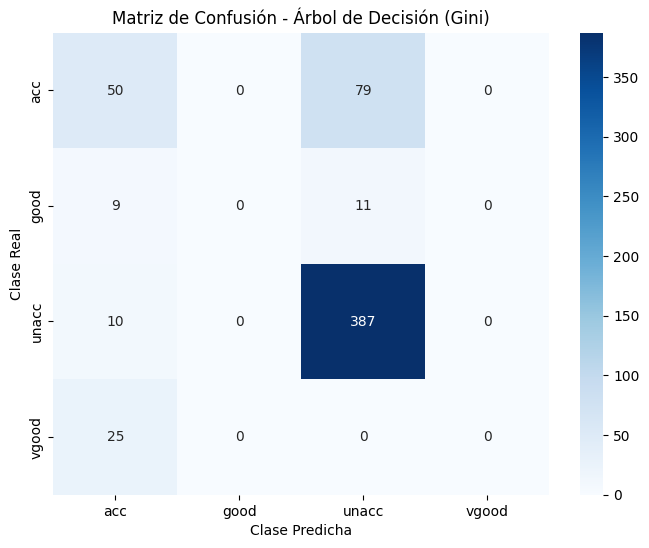

In [27]:
# 1. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gini)

# 2. Obtener los nombres de las clases
class_names = label_encoders['class'].classes_

# 3. Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

# 4. Agregar título y etiquetas
plt.title('Matriz de Confusión - Árbol de Decisión (Gini)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')

# 5. Mostrar la figura
plt.show()


In [28]:
# TODO: Imprimir el reporte de clasificación

# Imprimir el reporte de clasificación
print("Reporte de Clasificación - Modelo Gini")
print(classification_report(
    y_test,
    y_pred_gini,
    target_names=class_names
))



Reporte de Clasificación - Modelo Gini
              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C) unacc (inaceptable)

## Parte 9: Visualización del Árbol de Decisión

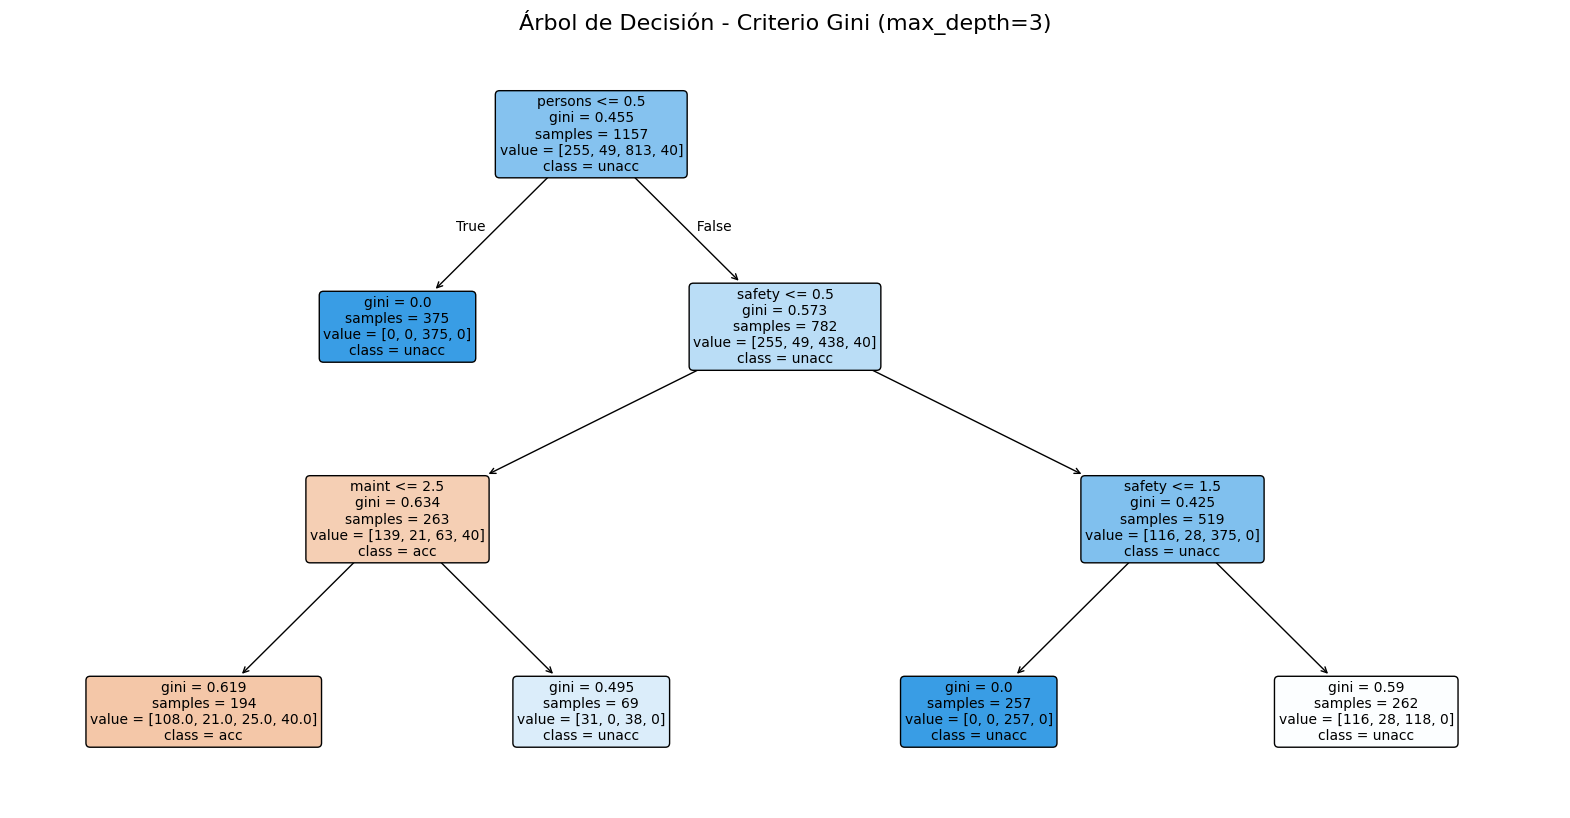

In [29]:
# TODO: Visualizar el árbol de decisión con Gini

# Crear una figura grande
plt.figure(figsize=(20, 10))

# Dibujar el árbol de decisión
plot_tree(
    clf_gini,
    feature_names=list(X.columns),
    class_names=list(class_names),
    filled=True,
    rounded=True,
    fontsize=10
)

# Agregar título
plt.title("Árbol de Decisión - Criterio Gini (max_depth=3)", fontsize=16)

# Mostrar la figura
plt.show()



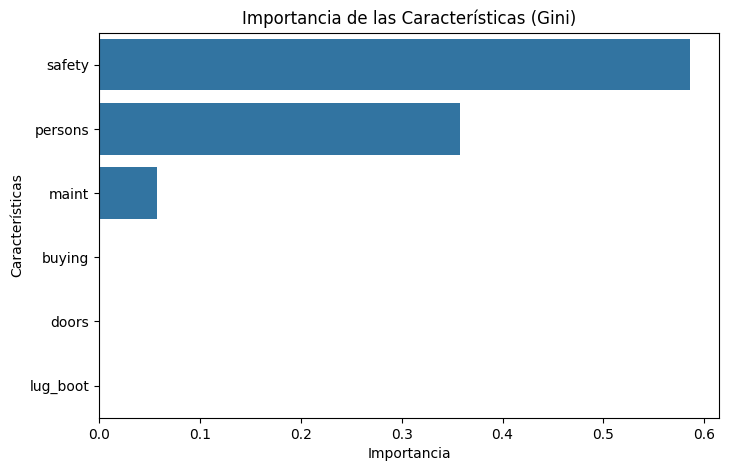

Importancia de las características:
    Feature  Importance
5    safety    0.585506
3   persons    0.357400
1     maint    0.057095
0    buying    0.000000
2     doors    0.000000
4  lug_boot    0.000000


In [30]:
# TODO: Mostrar la importancia de las características

# 1. Crear un DataFrame con las importancias
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf_gini.feature_importances_
})

# 2. Ordenar por importancia de mayor a menor
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# 3. Visualizar con un gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Importancia de las Características (Gini)')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

# 4. Imprimir la tabla de importancias
print("Importancia de las características:")
print(feature_importance)



### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C) safety (seguridad)  

## Parte 10: Experimentación con Hiperparámetros

In [32]:
# TODO: Experimentar con diferentes valores de max_depth

# 1. Definir los valores de max_depth
depths = [1, 2, 3, 5, 7, 10, None]

# 2. Crear una lista para almacenar los resultados
resultados = []

# 3. Entrenar y evaluar un modelo para cada profundidad
for depth in depths:

    # a. Crear y entrenar el modelo
    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    # b. Calcular precisión en entrenamiento
    train_pred = modelo.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)

    # Calcular precisión en prueba
    test_pred = modelo.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)

    # c. Guardar los resultados
    resultados.append({
        'max_depth': depth,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Profundidad': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves()
    })

# 4. Convertir a DataFrame e imprimir
resultados_df = pd.DataFrame(resultados)

print("Resultados de la experimentación:")
print(resultados_df)



Resultados de la experimentación:
   max_depth  Train Accuracy  Test Accuracy  Profundidad  Hojas
0        1.0          0.7027         0.6953            1      2
1        2.0          0.7684         0.7706            2      3
2        3.0          0.7744         0.7653            3      5
3        5.0          0.8557         0.8651            5     13
4        7.0          0.9300         0.9352            7     28
5       10.0          0.9931         0.9615           10     62
6        NaN          1.0000         0.9667           14     73


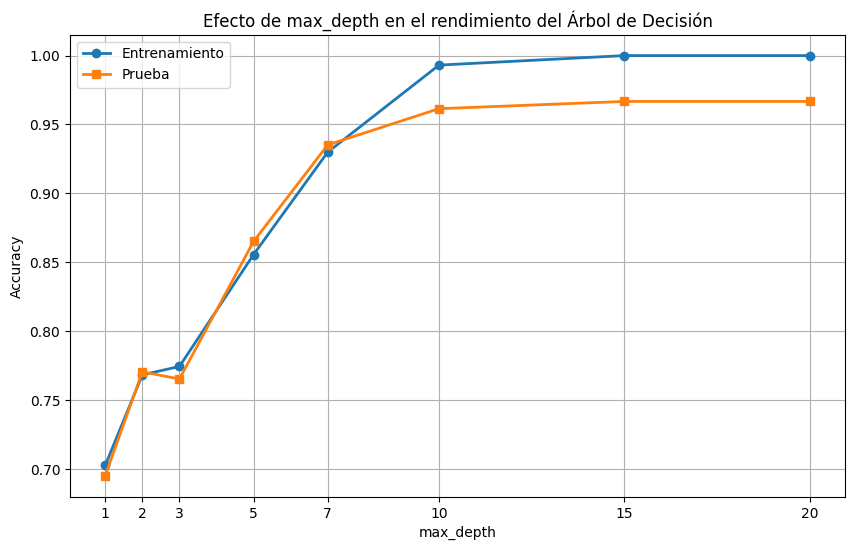

In [33]:
# 1. Definir los valores de max_depth
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]

# 2. Crear listas para almacenar las precisiones
train_scores = []
test_scores = []

# 3. Entrenar un modelo para cada profundidad
for depth in depths_plot:

    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Guardar precisión en entrenamiento
    train_scores.append(
        accuracy_score(y_train, model.predict(X_train))
    )

    # Guardar precisión en prueba
    test_scores.append(
        accuracy_score(y_test, model.predict(X_test))
    )

# 4. Graficar ambas curvas
plt.figure(figsize=(10,6))

plt.plot(depths_plot, train_scores,
         marker='o',
         linewidth=2,
         label='Entrenamiento')

plt.plot(depths_plot, test_scores,
         marker='s',
         linewidth=2,
         label='Prueba')

# 5. Agregar leyenda, título y etiquetas
plt.title('Efecto de max_depth en el rendimiento del Árbol de Decisión')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.xticks(depths_plot)
plt.grid(True)
plt.legend()

plt.show()


### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)

In [34]:
# 1. Definir los valores de min_samples_split
min_samples_list = [2, 5, 10, 20, 50]

# 2. Crear una lista para guardar los resultados
resultados_min_samples = []

# 3. Entrenar un modelo para cada valor
for min_samples in min_samples_list:

    # Crear el modelo (sin limitar max_depth)
    modelo = DecisionTreeClassifier(
        criterion='gini',
        min_samples_split=min_samples,
        random_state=42
    )

    # Entrenar el modelo
    modelo.fit(X_train, y_train)

    # Calcular precisión en entrenamiento
    train_acc = accuracy_score(y_train, modelo.predict(X_train))

    # Calcular precisión en prueba
    test_acc = accuracy_score(y_test, modelo.predict(X_test))

    # Guardar resultados
    resultados_min_samples.append({
        'min_samples_split': min_samples,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Profundidad': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves()
    })

# 4. Convertir a DataFrame e imprimir
resultados_min_df = pd.DataFrame(resultados_min_samples)

print("Resultados de la experimentación con min_samples_split:")
print(resultados_min_df)

Resultados de la experimentación con min_samples_split:
   min_samples_split  Train Accuracy  Test Accuracy  Profundidad  Hojas
0                  2          1.0000         0.9667           14     73
1                  5          0.9914         0.9562           12     62
2                 10          0.9767         0.9422           11     49
3                 20          0.9533         0.9317           10     38
4                 50          0.8911         0.8862            8     19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B) El número mínimo de muestras para dividir un nodo  

## Parte 11: Modelo Final Optimizado

In [35]:
# 1. Crear el modelo final
modelo_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_split=5,
    random_state=42
)

# 2. Entrenar el modelo
modelo_final.fit(X_train, y_train)

# 3. Calcular precisión en entrenamiento
y_train_pred_final = modelo_final.predict(X_train)
train_accuracy_final = accuracy_score(y_train, y_train_pred_final)

# Calcular precisión en prueba
y_test_pred_final = modelo_final.predict(X_test)
test_accuracy_final = accuracy_score(y_test, y_test_pred_final)

# Mostrar las precisiones
print("Precisión en entrenamiento:", round(train_accuracy_final, 4))
print("Precisión en prueba:", round(test_accuracy_final, 4))

# 4. Mostrar profundidad y número de hojas
print("Profundidad del árbol:", modelo_final.get_depth())
print("Número de hojas:", modelo_final.get_n_leaves())



Precisión en entrenamiento: 0.9283
Precisión en prueba: 0.9335
Profundidad del árbol: 7
Número de hojas: 27


In [36]:
# TODO: Imprimir reporte de clasificación final

# Obtener las predicciones del modelo final
y_pred_final = modelo_final.predict(X_test)

# Imprimir el reporte de clasificación
print("Reporte de Clasificación - Modelo Final Optimizado")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=class_names
))


Reporte de Clasificación - Modelo Final Optimizado
              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** D) 95-100%

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B) Son fáciles de interpretar y visualizar

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C) Tienden a sobreajustar si no se limita su complejidad